>架構：
1. SMOTE 使少量的樣本數量變多
2. 使用 LASSO 選Ｘ
   - XGB model預測
   - SVM model預測
   - RF model預測
4. 使用 XGB 選Ｘ
   - XGB model預測
   - SVM model預測
   - RF model預測

In [4]:
import pandas as pd
pd.set_option('display.max_columns', None) 

In [6]:
df = pd.read_csv('clean_data.csv', low_memory=False)

In [25]:
df.shape

(56741, 291)

In [26]:
df.head()

,gvkey,datadate,sic,dummy_costat,tic,conm,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,PERMNO,delist date,delist year,year,dummy_delist,dummy_delistconm,sic_rank,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing,dummy_PERMNO_missing,dummy_delist date_missing,dummy_delist year_missing
0,1004,2019-05-31,5080,0,AIR,AAR CORP,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.2386

In [7]:
# 跑 LR前先 drop 非數值的欄位
#exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank']
exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank','dummy_PERMNO_missing','dummy_delist date_missing','dummy_delist year_missing']
data=df.drop(exclude_list,axis=1)

In [28]:
data.head()

,dummy_costat,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,year,dummy_delist,dummy_delistconm,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing
0,0,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.238669,NaN,NaN,7.671501,NaN,NaN,NaN,NaN,NaN,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [8]:
# 按時間分測試集2024和訓練集2019-2023
X = data.drop(columns=['dummy_delistconm'])# 特徵欄位 測試集2024
y = data['dummy_delistconm']

# 根據年代分割
X_train = X[data['year'].between(2019, 2023)]
y_train = y[data['year'].between(2019, 2023)]

X_test = X[data['year'] == 2024]
y_test = y[data['year'] == 2024]

# 確認分割結果
print("訓練集大小:", X_train.shape, "測試集大小:", X_test.shape)

訓練集大小: (46960, 278) 測試集大小: (9781, 278)


Data Cleaning fill na

In [9]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

In [10]:
# 用 中位數""補 missing value
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

<h4>Handle Class Imbalance (SMOTE)</h4>

In [11]:
print("Before SMOTE:", Counter(y_train))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_res))

Before SMOTE: Counter({0: 46742, 1: 218})
After SMOTE: Counter({0: 46742, 1: 46742})


Feature Scaling

In [12]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

<h3> without feature selection</h3>

<h4> XGB </h4>

In [13]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_scaled, y_res)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)


Accuracy: 0.9979552193027298
AUC: 0.97965503122121

Classification Report:
               precision    recall  f1-score   support

           0     0.9993    0.9987    0.9990      9769
           1     0.2778    0.4167    0.3333        12

    accuracy                         0.9980      9781
   macro avg     0.6385    0.7077    0.6662      9781
weighted avg     0.9984    0.9980    0.9982      9781



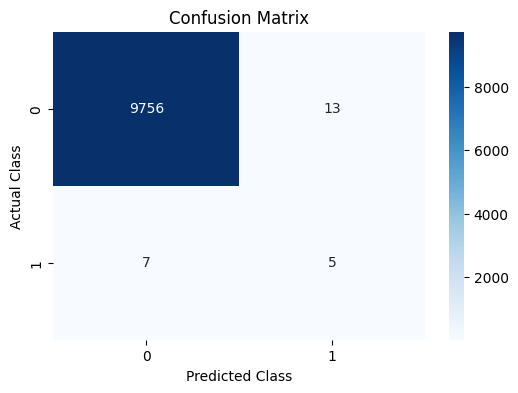

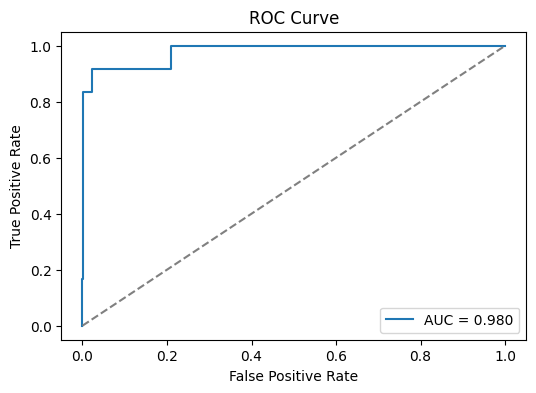

In [15]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

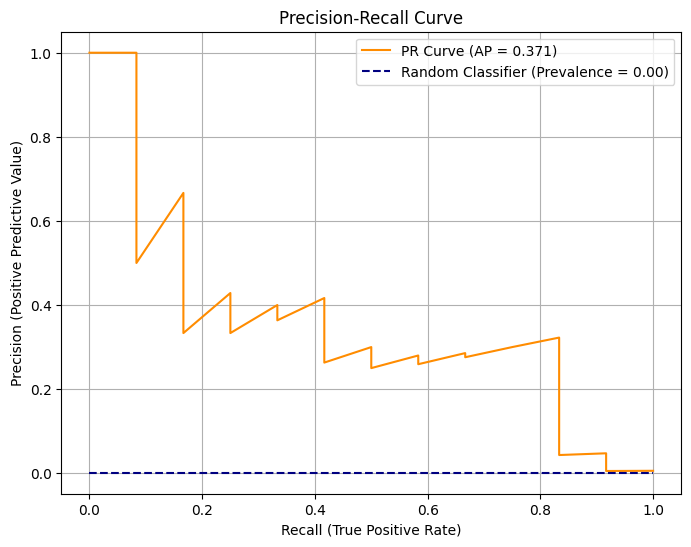

Average Precision (AP) Score: 0.371


In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4> Random forest</h4>

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9852775789796544
AUC: 0.9469324734705019

Classification Report:
               precision    recall  f1-score   support

           0     0.9990    0.9863    0.9926      9769
           1     0.0147    0.1667    0.0270        12

    accuracy                         0.9853      9781
   macro avg     0.5068    0.5765    0.5098      9781
weighted avg     0.9978    0.9853    0.9914      9781



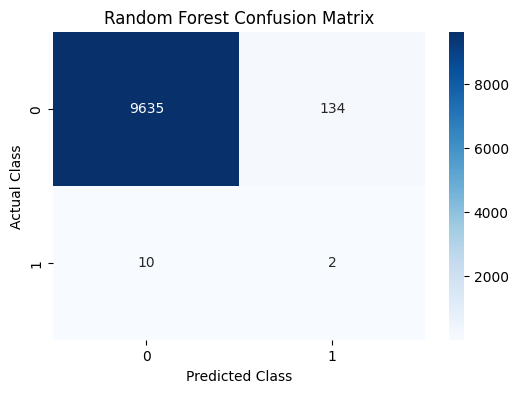

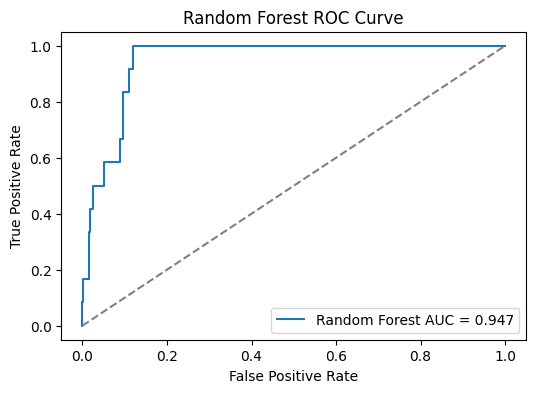

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好a，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_scaled, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_scaled)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

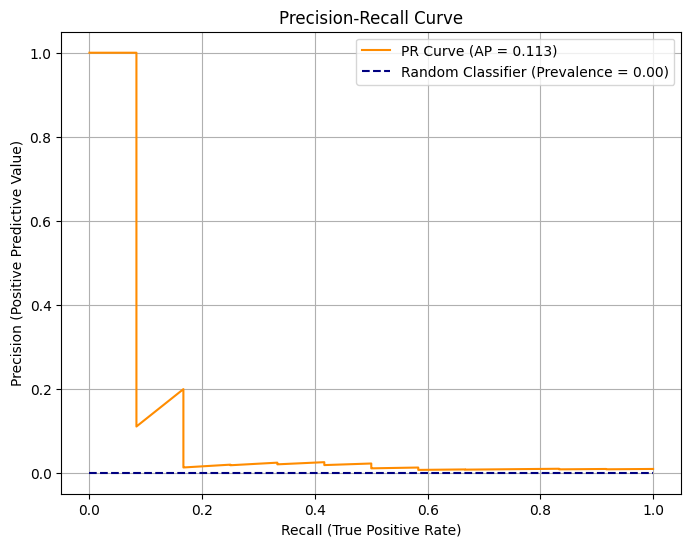

Average Precision (AP) Score: 0.113


In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9944790921173704
AUC: 0.9948135257788243

Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9947    0.9972      9769
           1     0.1613    0.8333    0.2703        12

    accuracy                         0.9945      9781
   macro avg     0.5805    0.9140    0.6337      9781
weighted avg     0.9988    0.9945    0.9963      9781



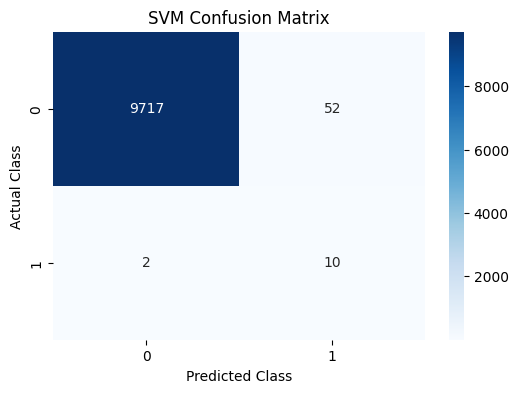

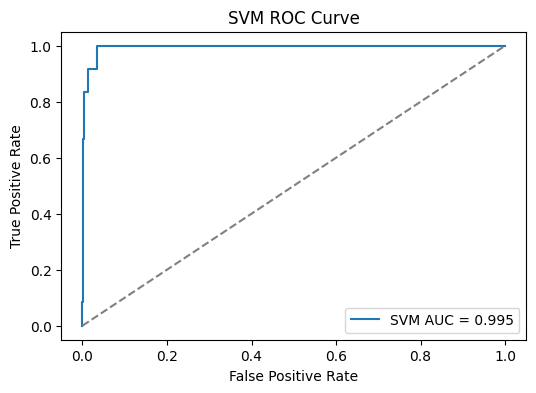

In [24]:
# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好
from sklearn.svm import SVC # 導入 SVM 分類器
print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_scaled, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_scaled)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

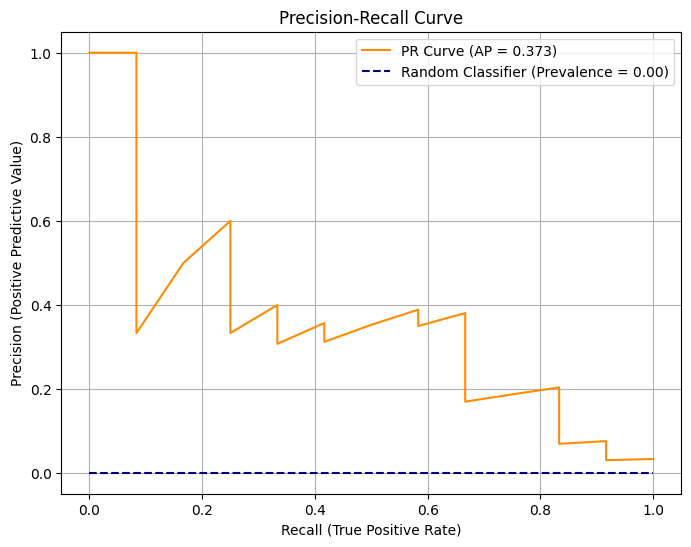

Average Precision (AP) Score: 0.373


In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h3>Feature Selection (LASSO)</h3>

In [45]:
# --- 重新載入 lasso_selector ---
lasso_selector = joblib.load('lasso_feature_selector.joblib')
print("Lasso selector 載入成功。")

# retain features with nonzero coefficients
selected_mask = lasso_selector.coef_[0] != 0
selected_features = X.columns[selected_mask]
print(f"Selected features ({len(selected_features)}): {list(selected_features)}")

# reduce data
X_res_selected = X_res_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]


Lasso selector 載入成功。
Selected features (129): ['dummy_costat', 'aco', 'act', 'artfs', 'ceq', 'dlc', 'dltt', 'dptc', 'esopt', 'ialti', 'icapt', 'intan', 'invt', 'ivpt', 'ivst', 'lco', 'lcuacu', 'npat', 'pvt', 'rect', 'ret', 'rvdt', 'rveqt', 'dvt', 'idit', 'revt', 'uopi', 'xint', 'xlr', 'xopr', 'year', 'dummy_delist', 'dummy_100', 'dummy_200', 'dummy_700', 'dummy_800', 'dummy_1000', 'dummy_1200', 'dummy_1300', 'dummy_1400', 'dummy_1500', 'dummy_1600', 'dummy_1700', 'dummy_2000', 'dummy_2100', 'dummy_2200', 'dummy_2300', 'dummy_2400', 'dummy_2500', 'dummy_2600', 'dummy_2700', 'dummy_2800', 'dummy_2900', 'dummy_3000', 'dummy_3100', 'dummy_3200', 'dummy_3300', 'dummy_3400', 'dummy_3500', 'dummy_3600', 'dummy_3700', 'dummy_3800', 'dummy_3900', 'dummy_4000', 'dummy_4100', 'dummy_4200', 'dummy_4400', 'dummy_4500', 'dummy_4600', 'dummy_4700', 'dummy_4800', 'dummy_4900', 'dummy_5000', 'dummy_5100', 'dummy_5300', 'dummy_5400', 'dummy_5500', 'dummy_5600', 'dummy_5700', 'dummy_5800', 'dummy_5900', 

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,


<h4>XGB</h4>

In [46]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_selected, y_res)


XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)

In [51]:
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_lasso_xgb_model.joblib'

# 儲存模型
joblib.dump(xgb_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_lasso_xgb_model.joblib


Model Evaluation


Accuracy: 0.9981596973724568
AUC: 0.9876906541099396

Classification Report:
               precision    recall  f1-score   support

           0     0.9996    0.9986    0.9991      9769
           1     0.3636    0.6667    0.4706        12

    accuracy                         0.9982      9781
   macro avg     0.6816    0.8326    0.7348      9781
weighted avg     0.9988    0.9982    0.9984      9781



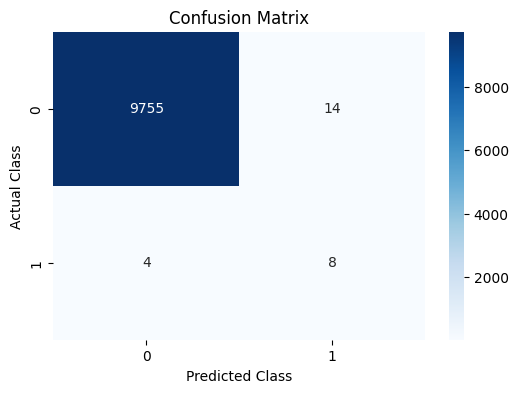

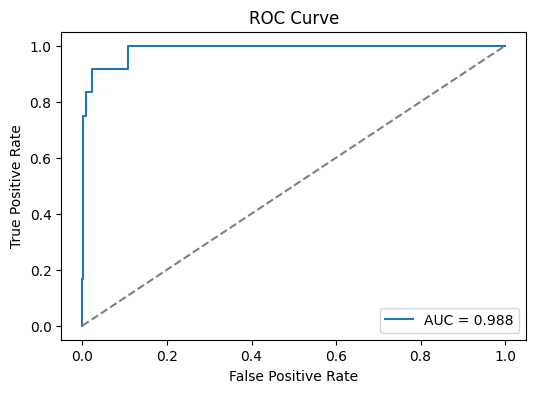

In [48]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_selected)
y_prob = xgb_model.predict_proba(X_test_selected)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

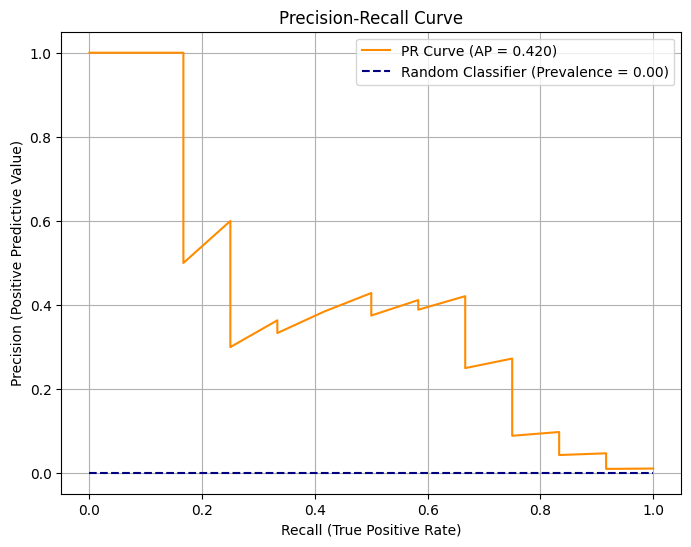

Average Precision (AP) Score: 0.420


In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9953992434311421
AUC: 0.9942078684273381

Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9957    0.9977      9769
           1     0.1765    0.7500    0.2857        12

    accuracy                         0.9954      9781
   macro avg     0.5881    0.8729    0.6417      9781
weighted avg     0.9987    0.9954    0.9968      9781



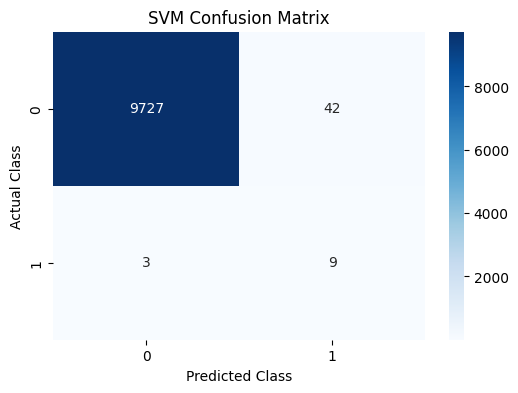

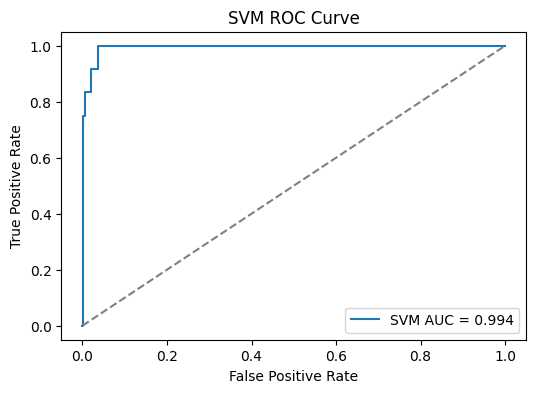

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC # 導入 SVM 分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_selected, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_selected)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

In [66]:
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_lasso_svm_model.joblib'

# 儲存模型
joblib.dump(svm_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_lasso_svm_model.joblib


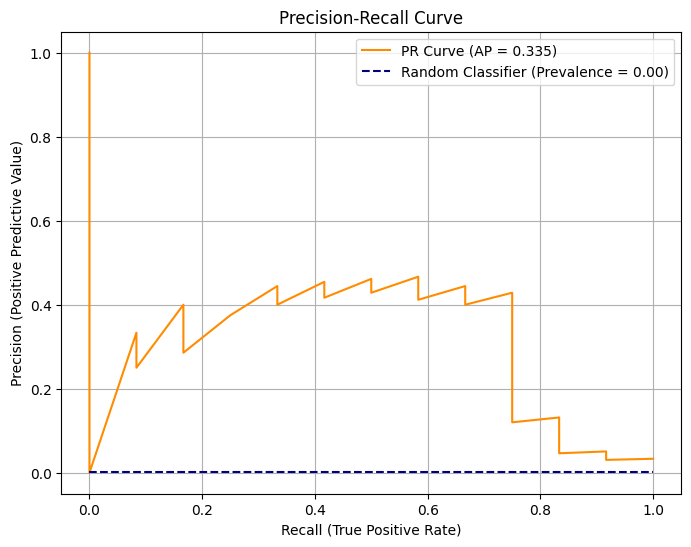

Average Precision (AP) Score: 0.335


In [68]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>RF</h4>

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9987731315816378
AUC: 0.9833401576415192

Classification Report:
               precision    recall  f1-score   support

           0     0.9992    0.9996    0.9994      9769
           1     0.5000    0.3333    0.4000        12

    accuracy                         0.9988      9781
   macro avg     0.7496    0.6665    0.6997      9781
weighted avg     0.9986    0.9988    0.9987      9781



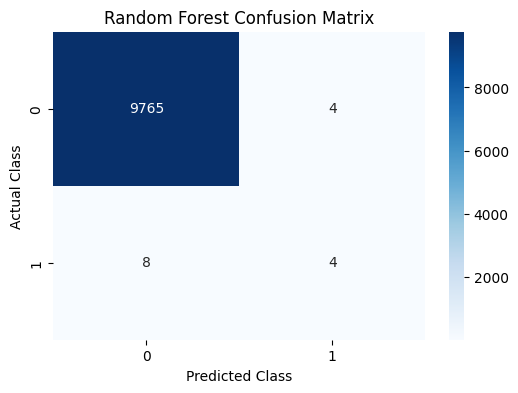

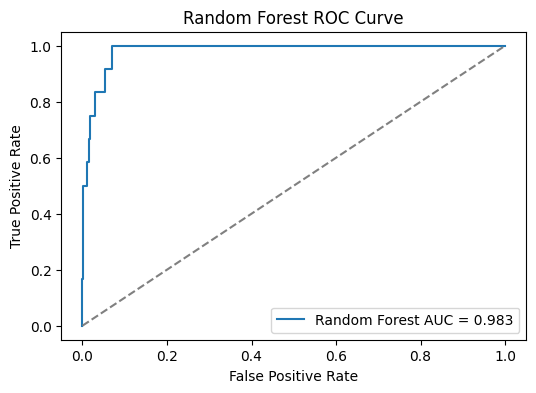

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_selected, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_selected)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

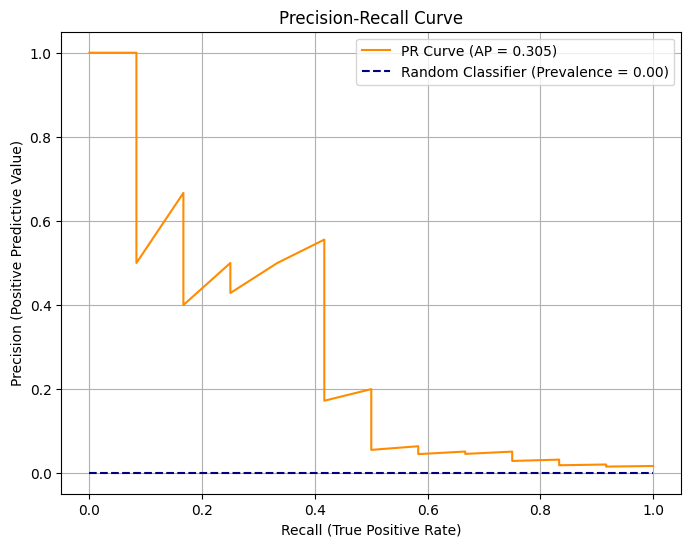

Average Precision (AP) Score: 0.305


In [59]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

In [69]:
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_lasso_rf_model.joblib'

# 儲存模型
joblib.dump(rf_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_lasso_rf_model.joblib


<h3>Feature Selection (XGB)</h3>

XGBoost selector (原生方法) 載入成功。

Feature Importances (Top 20):
                feature  importance
216  dummy_mrct_missing    0.218884
111          dummy_1300    0.046736
29                 ivpt    0.046420
180    dummy_at_missing    0.036113
68              citotal    0.034005
103                year    0.032749
178   dummy_act_missing    0.027334
164          dummy_7300    0.025612
22                intan    0.025234
161          dummy_6700    0.023491
30                 ivst    0.022529
0          dummy_costat    0.020810
87                 revt    0.019761
90                  txt    0.017812
97                 xopr    0.017082
8                   dlc    0.016801
6                   ceq    0.016503
21                icapt    0.015757
5                    at    0.015679
53                 rvdt    0.015233


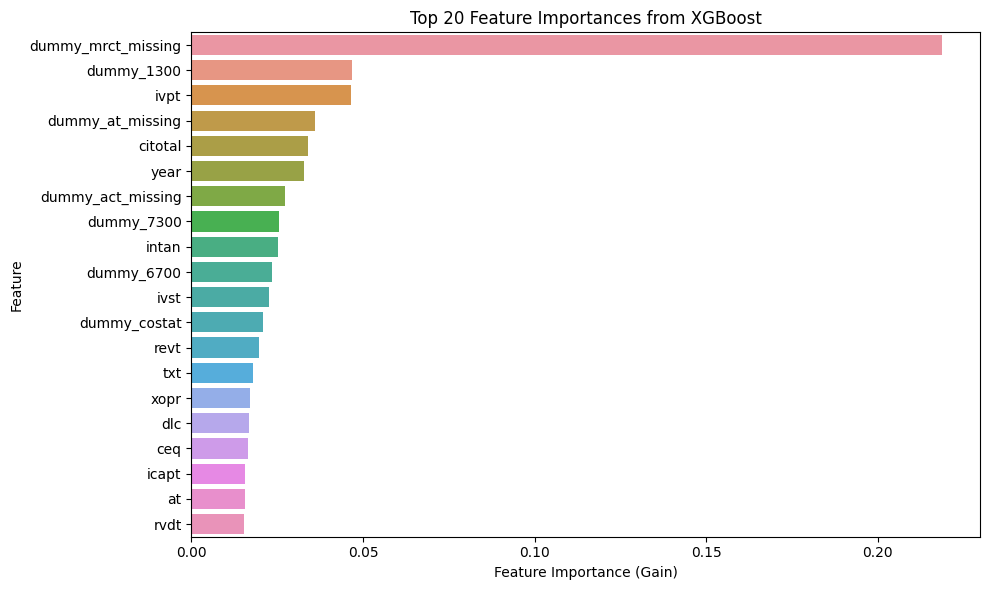


Number of features selected by XGBoost: 129
Selected features: ['dummy_mrct_missing', 'dummy_1300', 'ivpt', 'dummy_at_missing', 'citotal', 'year', 'dummy_act_missing', 'dummy_7300', 'intan', 'dummy_6700', 'ivst', 'dummy_costat', 'revt', 'txt', 'xopr', 'dlc', 'ceq', 'icapt', 'at', 'rvdt', 'tstk', 'dummy_2800', 'ppegt', 'xint', 'dummy_6000', 'pstk', 'dummy_3800', 'xagt', 'act', 'rect', 'dummy_delist', 'dummy_3600', 'xlr', 'dltt', 'dummy_invt_missing', 'txndb', 'dummy_xint_missing', 'lct', 'idit', 'aco', 'mrct', 'lo', 'dummy_3500', 'dvt', 'dummy_4800', 'dummy_4900', 'dummy_5800', 'ppent', 'dummy_5000', 'lt', 'dummy_7900', 'dummy_dptc_missing', 'dummy_8700', 'dummy_3400', 'dummy_4500', 'dummy_5200', 'dummy_5900', 'invt', 'lco', 'dummy_dltt_missing', 'dummy_aco_missing', 'dummy_istm_missing', 'dummy_7800', 'dummy_isut_missing', 'dummy_ivpt_missing', 'dummy_ivst_missing', 'dummy_lcabg_missing', 'dummy_8100', 'dummy_9900', 'dummy_acoxar_missing', 'dummy_7600', 'dummy_lcat_missing', 'dummy_lc

In [16]:
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
# --- 重新載入 XGBoost selector (原生方法) ---
xgb_selector = xgb.XGBClassifier() # 必須先創建一個空的 XGBClassifier 實例
xgb_selector.load_model('xgb_feature_selector_native.json')
print("XGBoost selector (原生方法) 載入成功。")
# 3. 獲取特徵重要性
# 預設情況下，feature_importances_ 使用 'gain' (分裂後損失的平均減少量)
# 您也可以通過 xgb_selector.get_booster().get_score(importance_type='weight') 等方式獲取其他類型的重要性
feature_importances = xgb_selector.feature_importances_
feature_names = X.columns # 獲取原始特徵名稱

# 將特徵名稱和重要性配對，並按重要性降序排列
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 20):")
print(importance_df.head(20))

# 可視化特徵重要性 (可選)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from XGBoost')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 4. 根據重要性選擇特徵
# 有兩種常見方法：
#   a) 選擇前 N 個特徵 (常用)
#   b) 設定一個重要性閾值，選擇所有重要性高於該閾值的特徵

# --- 方法 a): 選擇前 N 個特徵 ---
num_features_to_select = 129 # 這裡設定您希望選擇的特徵數量
selected_features_xgb = importance_df.head(num_features_to_select)['feature'].tolist()

# --- 方法 b): 選擇重要性高於閾值的特徵 (另一種選擇) ---
# importance_threshold = 0.005 # 這裡設定您希望的閾值
# selected_features_xgb = importance_df[importance_df['importance'] > importance_threshold]['feature'].tolist()


print(f"\nNumber of features selected by XGBoost: {len(selected_features_xgb)}")
print(f"Selected features: {selected_features_xgb}")

# 5. 創建布林遮罩並縮減數據
# 確保遮罩的順序與原始數據的列順序一致
selected_mask_xgb = X.columns.isin(selected_features_xgb)

X_res_selected_2 = X_res_scaled[:, selected_mask_xgb]
X_test_selected_2 = X_test_scaled[:, selected_mask_xgb]

print(f"\nShape of X_res_selected after XGBoost feature selection: {X_res_selected_2.shape}")
print(f"Shape of X_test_selected after XGBoost feature selection: {X_test_selected_2.shape}")

print("\n--- XGBoost Feature Selection Complete ---")

<h4>XGB</h4>

In [17]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_selected_2, y_res)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)

In [19]:
import joblib
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_xgb_xgb_model.joblib'

# 儲存模型
joblib.dump(xgb_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_xgb_xgb_model.joblib



Accuracy: 0.9988753706165013
AUC: 0.9803204012693213

Classification Report:
               precision    recall  f1-score   support

           0     0.9994    0.9995    0.9994      9769
           1     0.5455    0.5000    0.5217        12

    accuracy                         0.9989      9781
   macro avg     0.7724    0.7497    0.7606      9781
weighted avg     0.9988    0.9989    0.9989      9781



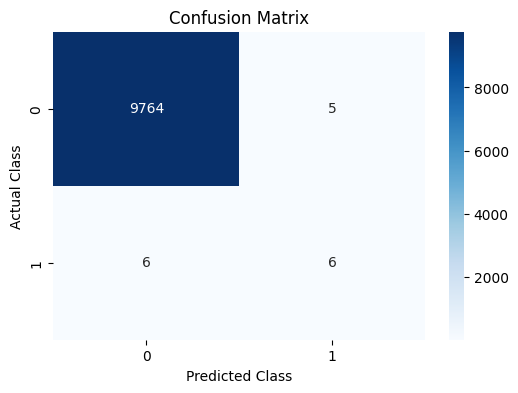

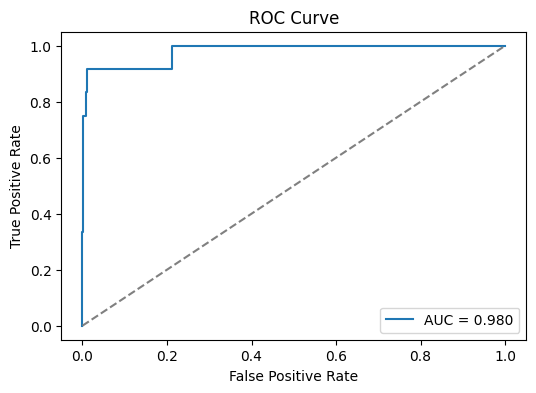

In [21]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_selected_2)
y_prob = xgb_model.predict_proba(X_test_selected_2)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

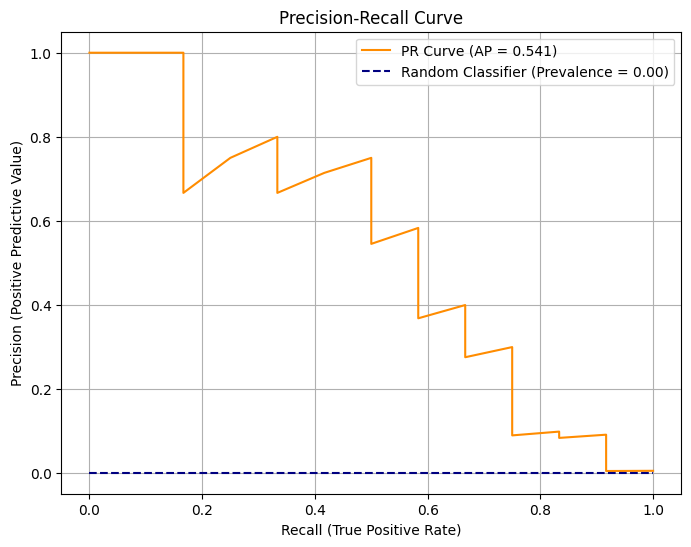

Average Precision (AP) Score: 0.541


In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9919231162457827
AUC: 0.9821245777459311

Classification Report:
               precision    recall  f1-score   support

           0     0.9996    0.9923    0.9959      9769
           1     0.0964    0.6667    0.1684        12

    accuracy                         0.9919      9781
   macro avg     0.5480    0.8295    0.5822      9781
weighted avg     0.9985    0.9919    0.9949      9781



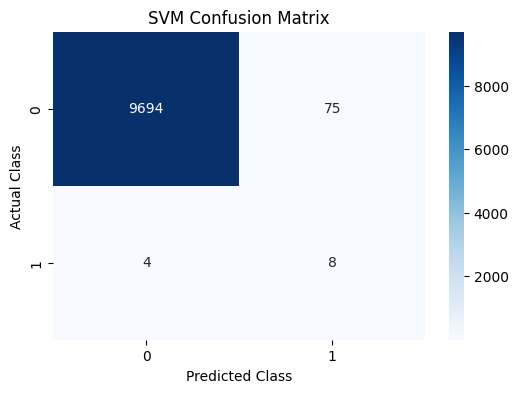

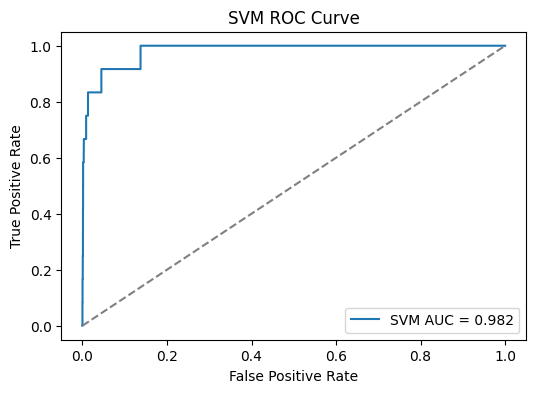

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC # 導入 SVM 分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_selected_2, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_selected_2)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_selected_2)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

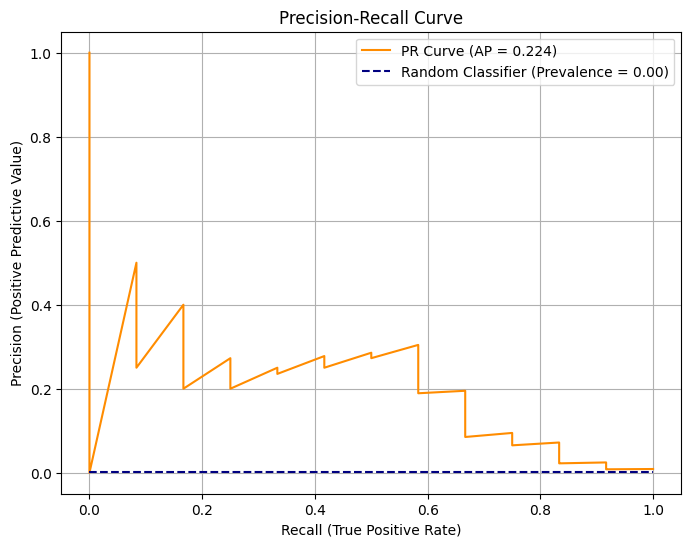

Average Precision (AP) Score: 0.224


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

In [26]:
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_xgb_svm_model.joblib'

# 儲存模型
joblib.dump(svm_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_xgb_svm_model.joblib


<h4>RF</h4>

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9981596973724568
AUC: 0.9672177295526666

Classification Report:
               precision    recall  f1-score   support

           0     0.9991    0.9991    0.9991      9769
           1     0.2500    0.2500    0.2500        12

    accuracy                         0.9982      9781
   macro avg     0.6245    0.6245    0.6245      9781
weighted avg     0.9982    0.9982    0.9982      9781



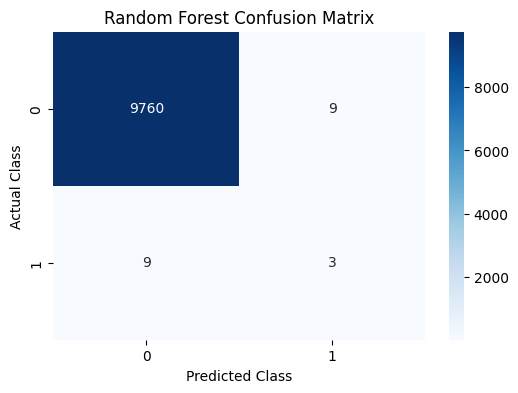

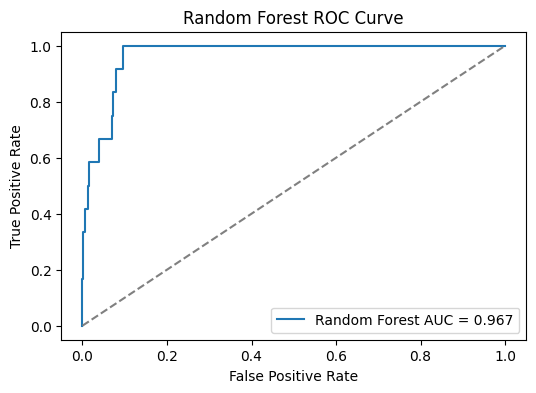

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_selected_2, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_selected_2)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_selected_2)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

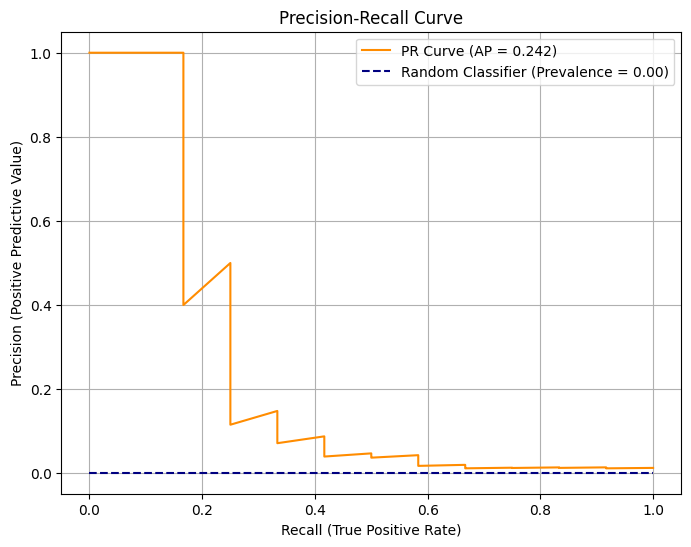

Average Precision (AP) Score: 0.242


In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

In [30]:
from sklearn.impute import SimpleImputer
# --- 儲存模型和插補器 ---
# 定義儲存檔案的路徑和名稱
model_filename = 'feature_selection_xgb_rf_model.joblib'

# 儲存模型
joblib.dump(rf_model, model_filename)
print(f"模型已儲存為：{model_filename}")

模型已儲存為：feature_selection_xgb_rf_model.joblib
